# ENTRENAMIENTO DEL MODELO

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("PASO 1: CARGAR DATOS")
print("="*80)

df = pd.read_csv('../data/processed/vehicles_with_features.csv')

print(f"Dataset cargado: {df.shape}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df.columns

PASO 1: CARGAR DATOS
Dataset cargado: (249706, 21)
Valores nulos: 0


Index(['price', 'cylinders', 'odometer', 'manufacturer', 'condition', 'fuel',
       'transmission', 'drive', 'type', 'state', 'age', 'condition_encoded',
       'log_odometer', 'mileage_per_year', 'cylinders_squared',
       'age_x_condition', 'age_x_log_odometer', 'cylinders_x_condition',
       'is_automatic', 'is_4wd', 'is_rwd'],
      dtype='object')


PASO 2: ANÁLISIS EXPLORATORIO RÁPIDO

2.1 DISTRIBUCIÓN DEL PRECIO (TARGET)
count    249706.000000
mean      17964.362498
std       14532.374662
min         500.000000
25%        6995.000000
50%       14000.000000
75%       25900.000000
max      449500.000000
Name: price, dtype: float64
✓ Gráfico guardado: price_distribution.png


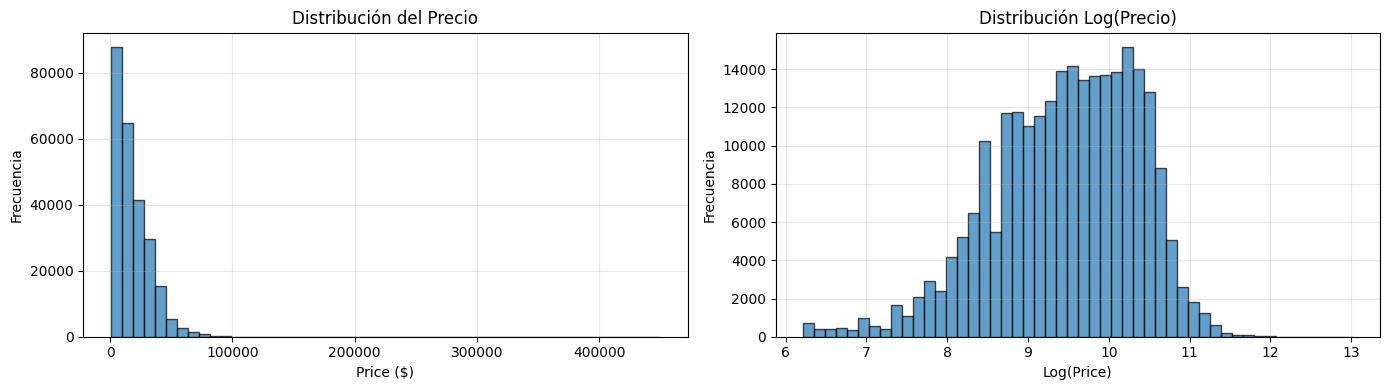


2.2 ESTADÍSTICAS DE FEATURES NUMÉRICAS
               price      cylinders       odometer            age  \
count  249706.000000  249706.000000  249706.000000  249706.000000   
mean    17964.362498       5.829343   96845.872094      13.451935   
std     14532.374662       1.481179   62532.004071       6.592961   
min       500.000000       3.000000       0.000000       3.000000   
25%      6995.000000       4.000000   42581.000000       8.000000   
50%     14000.000000       6.000000   93235.500000      12.000000   
75%     25900.000000       7.000000  140000.000000      17.000000   
max    449500.000000      12.000000  300000.000000      45.000000   

       condition_encoded   log_odometer  mileage_per_year  cylinders_squared  \
count      249706.000000  249706.000000     249706.000000      249706.000000   
mean            2.610354      11.069368       6559.041492          36.175126   
std             0.652236       1.389487       3530.240649          17.959042   
min             0.

In [5]:
print("\n" + "="*80)
print("PASO 2: ANÁLISIS EXPLORATORIO RÁPIDO")
print("="*80)

# 2.1 Distribución del target
print("\n2.1 DISTRIBUCIÓN DEL PRECIO (TARGET)")
print(df['price'].describe())

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Precio')
axes[0].grid(alpha=0.3)

axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución Log(Precio)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado: price_distribution.png")
plt.show()

# 2.2 Estadísticas numéricas
print("\n2.2 ESTADÍSTICAS DE FEATURES NUMÉRICAS")
print(df.select_dtypes(include=[np.number]).describe())

# 2.3 Correlación con el target
print("\n2.3 CORRELACIÓN CON PRECIO (Top 10)")
correlations = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlations.head(11))  # 11 para incluir el mismo price

# 2.4 Variables categóricas
print("\n2.4 VARIABLES CATEGÓRICAS")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} categorías")
    print(df[col].value_counts().head(5))

In [6]:
print("\n" + "="*80)
print("PASO 3: ANÁLISIS DE OUTLIERS")
print("="*80)

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1: ${Q1:,.0f}")
print(f"Q3: ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"Rango normal: ${lower_bound:,.0f} - ${upper_bound:,.0f}")

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nOutliers detectados: {len(outliers):,} ({100*len(outliers)/len(df):.2f}%)")
print(f"Precios por debajo de Q1-1.5*IQR: {(df['price'] < lower_bound).sum():,}")
print(f"Precios por encima de Q3+1.5*IQR: {(df['price'] > upper_bound).sum():,}")

# Decidir si eliminar outliers
print("\nOPCIONES:")
print("1. Mantener outliers (modelo más realista para casos extremos)")
print("2. Eliminar outliers (modelo más preciso para casos típicos)")
print("\n→ RECOMENDACIÓN: MANTENER (para proyecto educativo, ves todos los casos)")



PASO 3: ANÁLISIS DE OUTLIERS

Q1: $6,995
Q3: $25,900
IQR: $18,905
Rango normal: $-21,362 - $54,258

Outliers detectados: 5,514 (2.21%)
Precios por debajo de Q1-1.5*IQR: 0
Precios por encima de Q3+1.5*IQR: 5,514

OPCIONES:
1. Mantener outliers (modelo más realista para casos extremos)
2. Eliminar outliers (modelo más preciso para casos típicos)

→ RECOMENDACIÓN: MANTENER (para proyecto educativo, ves todos los casos)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# PASO 4: SPLIT TRAIN/TEST
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PASO 4: DIVIDIR EN TRAIN/TEST")
print("="*80)

# Separar features y target
X = df.drop('price', axis=1)
y = df['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nTrain: {X_train.shape[0]:,} registros ({100*0.8:.0f}%)")
print(f"Test: {X_test.shape[0]:,} registros ({100*0.2:.0f}%)")

# Verificar distribución de precios en train/test
print(f"\nPrecio promedio (Train): ${y_train.mean():,.0f}")
print(f"Precio promedio (Test): ${y_test.mean():,.0f}")
print(f"Diferencia: {abs(y_train.mean() - y_test.mean()) / y_train.mean() * 100:.2f}%")



PASO 4: DIVIDIR EN TRAIN/TEST

Train: 199,764 registros (80%)
Test: 49,942 registros (20%)

Precio promedio (Train): $17,940
Precio promedio (Test): $18,062
Diferencia: 0.68%


In [8]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"✓ Categóricas: {categorical_cols}")
print(f"✓ Numéricas: {numerical_cols}")

✓ Categóricas: ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type', 'state']
✓ Numéricas: ['cylinders', 'odometer', 'age', 'condition_encoded', 'log_odometer', 'mileage_per_year', 'cylinders_squared', 'age_x_condition', 'age_x_log_odometer', 'cylinders_x_condition', 'is_automatic', 'is_4wd', 'is_rwd']


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# PASO 5: ENCODING DE VARIABLES CATEGÓRICAS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PASO 5: ENCODING DE VARIABLES CATEGÓRICAS")
print("="*80)

all_encoders = {}
for col in categorical_cols:
    print(f"\n  Procesando: {col}")
    le = LabelEncoder()
    
    # Fit SOLO con train
    le.fit(X_train[col].astype(str))
    print(f"    → Vio {len(le.classes_)} categorías únicas")
    
    # Transform tanto train como test
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    
    # GUARDAR el encoder
    all_encoders[col] = le

print(f"\n✓ Total encoders guardados: {len(all_encoders)}")



PASO 5: ENCODING DE VARIABLES CATEGÓRICAS

  Procesando: manufacturer
    → Vio 41 categorías únicas

  Procesando: condition
    → Vio 6 categorías únicas

  Procesando: fuel
    → Vio 5 categorías únicas

  Procesando: transmission
    → Vio 3 categorías únicas

  Procesando: drive
    → Vio 3 categorías únicas

  Procesando: type
    → Vio 13 categorías únicas

  Procesando: state
    → Vio 51 categorías únicas

✓ Total encoders guardados: 7


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# PASO 6: NORMALIZACIÓN DE FEATURES NUMÉRICAS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PASO 6: NORMALIZACIÓN")
print("="*80)

# Identificar columnas numéricas
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNormalizando {len(numeric_features)} columnas numéricas")

# Escalar
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("✓ Normalización completada")
print(f"\nEjemplo (antes de normalizar):")
print(X_train[numeric_features].head())
print(f"\nEjemplo (después de normalizar):")
print(X_train_scaled[numeric_features].head())



PASO 6: NORMALIZACIÓN

Normalizando 20 columnas numéricas
✓ Normalización completada

Ejemplo (antes de normalizar):
        cylinders  odometer  manufacturer  condition  fuel  transmission  \
60231           8  175000.0             7          0     0             0   
69150          10  170904.0            16          2     2             0   
237339          6   60047.0            25          2     2             0   
122348          6  181000.0            20          2     2             0   
119044          4   17472.0            36          2     2             2   

        drive  type  state  age  condition_encoded  log_odometer  \
60231       2    10      9   21                  3     12.072547   
69150       0    11     10   15                  2     12.048863   
237339      1    12     47   11                  2     11.002900   
122348      0     6     22   16                  2     12.106258   
119044      0    12     22    7                  2      9.768412   

        mileage_

In [11]:
print(f"✓ Train: {X_train.shape[0]:,} registros")
print(f"✓ Test: {X_test.shape[0]:,} registros")
print(f"✓ Precio promedio (Train): ${y_train.mean():.2f}")
print(f"✓ Precio promedio (Test): ${y_test.mean():.2f}")

✓ Train: 199,764 registros
✓ Test: 49,942 registros
✓ Precio promedio (Train): $17939.95
✓ Precio promedio (Test): $18062.02


In [12]:

# Crear dataset de LightGBM
train_data_lgb = lgb.Dataset(X_train, label=y_train)
test_data_lgb = lgb.Dataset(X_test, label=y_test, reference=train_data_lgb)

# Parámetros de LightGBM
params_lgb = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'verbose': -1,
    'seed': 42,
    'num_threads': -1
}

# Entrenar
print("Entrenando... (esto puede tomar 1-2 minutos)")
model_lgb = lgb.train(
    params_lgb,
    train_data_lgb,
    num_boost_round=300,
    valid_sets=[train_data_lgb, test_data_lgb],
    valid_names=['train', 'test'],
    callbacks=[lgb.log_evaluation(period=50), lgb.early_stopping(stopping_rounds=50)]
)

Entrenando... (esto puede tomar 1-2 minutos)
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 7906.76	test's rmse: 8064.92
[100]	train's rmse: 7314.07	test's rmse: 7491.21
[150]	train's rmse: 7015.97	test's rmse: 7194.17
[200]	train's rmse: 6841.22	test's rmse: 7037.6
[250]	train's rmse: 6721.52	test's rmse: 6938.53
[300]	train's rmse: 6638.53	test's rmse: 6883.36
Did not meet early stopping. Best iteration is:
[300]	train's rmse: 6638.53	test's rmse: 6883.36


In [13]:
# Predicciones LightGBM
y_train_pred_lgb = model_lgb.predict(X_train)
y_test_pred_lgb = model_lgb.predict(X_test)

# Métricas LightGBM
mae_lgb_train = mean_absolute_error(y_train, y_train_pred_lgb)
rmse_lgb_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))
r2_lgb_train = r2_score(y_train, y_train_pred_lgb)

mae_lgb_test = mean_absolute_error(y_test, y_test_pred_lgb)
rmse_lgb_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb))
r2_lgb_test = r2_score(y_test, y_test_pred_lgb)

print("\n📊 RESULTADOS LIGHTGBM:")
print(f"  Train - MAE: ${mae_lgb_train:.2f} | RMSE: ${rmse_lgb_train:.2f} | R²: {r2_lgb_train:.4f}")
print(f"  Test  - MAE: ${mae_lgb_test:.2f} | RMSE: ${rmse_lgb_test:.2f} | R²: {r2_lgb_test:.4f}")



📊 RESULTADOS LIGHTGBM:
  Train - MAE: $3813.28 | RMSE: $6638.53 | R²: 0.7903
  Test  - MAE: $3850.36 | RMSE: $6883.36 | R²: 0.7797


In [14]:
# ============================================================================
# PASO 5: ENTRENAR XGBOOST
# ============================================================================
print("\n[PASO 5] Entrenando XGBoost...")
print("-" * 80)

# Parámetros de XGBoost
params_xgb = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

# Entrenar
print("Entrenando... (esto puede tomar 1-2 minutos)")
model_xgb = xgb.XGBRegressor(
    n_estimators=300,
    early_stopping_rounds=50,
    **params_xgb
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print("✓ XGBoost entrenado exitosamente")


[PASO 5] Entrenando XGBoost...
--------------------------------------------------------------------------------
Entrenando... (esto puede tomar 1-2 minutos)
✓ XGBoost entrenado exitosamente


In [15]:
# Predicciones XGBoost
y_train_pred_xgb = model_xgb.predict(X_train)
y_test_pred_xgb = model_xgb.predict(X_test)

# Métricas XGBoost
mae_xgb_train = mean_absolute_error(y_train, y_train_pred_xgb)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
r2_xgb_train = r2_score(y_train, y_train_pred_xgb)

mae_xgb_test = mean_absolute_error(y_test, y_test_pred_xgb)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
r2_xgb_test = r2_score(y_test, y_test_pred_xgb)

print("\n📊 RESULTADOS XGBOOST:")
print(f"  Train - MAE: ${mae_xgb_train:.2f} | RMSE: ${rmse_xgb_train:.2f} | R²: {r2_xgb_train:.4f}")
print(f"  Test  - MAE: ${mae_xgb_test:.2f} | RMSE: ${rmse_xgb_test:.2f} | R²: {r2_xgb_test:.4f}")


📊 RESULTADOS XGBOOST:
  Train - MAE: $3503.75 | RMSE: $5953.67 | R²: 0.8314
  Test  - MAE: $3642.28 | RMSE: $6494.89 | R²: 0.8039


In [16]:
# ============================================================================
# PASO 6: COMPARACIÓN DE MODELOS
# ============================================================================
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)

comparison_df = pd.DataFrame({
    'Métrica': ['MAE (Train)', 'RMSE (Train)', 'R² (Train)', 'MAE (Test)', 'RMSE (Test)', 'R² (Test)'],
    'LightGBM': [
        f"${mae_lgb_train:.2f}",
        f"${rmse_lgb_train:.2f}",
        f"{r2_lgb_train:.4f}",
        f"${mae_lgb_test:.2f}",
        f"${rmse_lgb_test:.2f}",
        f"{r2_lgb_test:.4f}"
    ],
    'XGBoost': [
        f"${mae_xgb_train:.2f}",
        f"${rmse_xgb_train:.2f}",
        f"{r2_xgb_train:.4f}",
        f"${mae_xgb_test:.2f}",
        f"${rmse_xgb_test:.2f}",
        f"{r2_xgb_test:.4f}"
    ]
})

print("\n")
print(comparison_df.to_string(index=False))

# Determinar mejor modelo
mejor_modelo = "LightGBM" if mae_lgb_test < mae_xgb_test else "XGBoost"
print(f"\n✓ Mejor modelo (menor MAE en Test): {mejor_modelo}")


COMPARACIÓN DE MODELOS


     Métrica LightGBM  XGBoost
 MAE (Train) $3813.28 $3503.75
RMSE (Train) $6638.53 $5953.67
  R² (Train)   0.7903   0.8314
  MAE (Test) $3850.36 $3642.28
 RMSE (Test) $6883.36 $6494.89
   R² (Test)   0.7797   0.8039

✓ Mejor modelo (menor MAE en Test): XGBoost


In [18]:
# Feature importance XGBoost
feature_importance_xgb = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': model_xgb.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

print("\n📊 Top 15 Features - XGBoost:")
print(feature_importance_xgb.to_string(index=False))


📊 Top 15 Features - XGBoost:
              feature  importance
                  age    0.239499
    cylinders_squared    0.125000
                 fuel    0.120109
   age_x_log_odometer    0.110216
            cylinders    0.076002
               is_4wd    0.054856
             odometer    0.033687
                drive    0.033026
               is_rwd    0.031411
cylinders_x_condition    0.022706
         log_odometer    0.021874
         manufacturer    0.020965
    condition_encoded    0.020814
         transmission    0.019591
      age_x_condition    0.017263


In [ ]:
# Feature importance LightGBM
feature_importance_lgb = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model_lgb.feature_importance()
}).sort_values('importance', ascending=False).head(15)

print("\n📊 Top 15 Features - LightGBM:")
print(feature_importance_lgb.to_string(index=False))


📊 Top 15 Features - LightGBM:
              feature  importance
         manufacturer        1707
                 type         884
             odometer         868
   age_x_log_odometer         807
            cylinders         716
                  age         606
     mileage_per_year         591
                 fuel         509
                drive         495
                state         493
cylinders_x_condition         444
      age_x_condition         411
         transmission         274
    condition_encoded          89
            condition          85


In [20]:
import joblib
import json
import os
from datetime import datetime

In [22]:
# Configurar paths para src/models/
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
SRC_MODEL_DIR = os.path.join(PROJECT_ROOT, "src", "models")

# Crear directorio si no existe
os.makedirs(SRC_MODEL_DIR, exist_ok=True)

# Rutas de guardado (usando la variable SRC_MODEL_DIR)
MODEL_PATH = os.path.join(SRC_MODEL_DIR, "xgboost_model.joblib")
ENCODERS_PATH = os.path.join(SRC_MODEL_DIR, "encoders.joblib")
METADATA_PATH = os.path.join(SRC_MODEL_DIR, "metadata.json")

In [23]:
# Guardar modelo
joblib.dump(model_xgb, MODEL_PATH)
print(f"✓ Modelo guardado: {MODEL_PATH}")

# Guardar TODOS los encoders en UN archivo
joblib.dump(all_encoders, ENCODERS_PATH)
print(f"✓ Encoders guardados: {ENCODERS_PATH}")
print(f"  → Contiene {len(all_encoders)} encoders:")
for col in all_encoders.keys():
    print(f"     - {col}")

# Crear metadata
metadata = {
    'model_type': 'XGBoost',
    'training_date': datetime.now().isoformat(),
    'metrics': {
        'mae_train': float(mae_xgb_train),
        'rmse_train': float(rmse_xgb_train),
        'r2_train': float(r2_xgb_train),
        'mae_test': float(mae_xgb_test),
        'rmse_test': float(rmse_xgb_test),
        'r2_test': float(r2_xgb_test)
    },
    'categorical_features': categorical_cols,
    'numerical_features': numerical_cols,
    'total_features': X_train.shape[1],
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata guardado: {METADATA_PATH}")

✓ Modelo guardado: /home/javif/UTA/Proyecto_Fabian/Proyecto_Autos_Usados/src/models/xgboost_model.joblib
✓ Encoders guardados: /home/javif/UTA/Proyecto_Fabian/Proyecto_Autos_Usados/src/models/encoders.joblib
  → Contiene 7 encoders:
     - manufacturer
     - condition
     - fuel
     - transmission
     - drive
     - type
     - state
✓ Metadata guardado: /home/javif/UTA/Proyecto_Fabian/Proyecto_Autos_Usados/src/models/metadata.json


In [24]:
# Cargar modelo
loaded_model = joblib.load(MODEL_PATH)
print(f"✓ Modelo cargado exitosamente")
print(f"  Tipo: {type(loaded_model).__name__}")

# Cargar encoders
loaded_encoders = joblib.load(ENCODERS_PATH)
print(f"\n✓ Encoders cargados exitosamente")
print(f"  Se cargaron {len(loaded_encoders)} encoders")

# Cargar metadata
with open(METADATA_PATH, 'r') as f:
    loaded_metadata = json.load(f)
print(f"\n✓ Metadata cargado exitosamente")
print(f"  R² Test: {loaded_metadata['metrics']['r2_test']:.4f}")
print(f"  MAE Test: ${loaded_metadata['metrics']['mae_test']:.2f}")

✓ Modelo cargado exitosamente
  Tipo: XGBRegressor

✓ Encoders cargados exitosamente
  Se cargaron 7 encoders

✓ Metadata cargado exitosamente
  R² Test: 0.8039
  MAE Test: $3642.28


In [25]:
print("\n[PASO 10] Prueba de predicción con modelo y encoders cargados...")
print("-" * 80)

# Tomar una muestra de test
sample_idx = 0
sample_encoded = X_test.iloc[[sample_idx]].copy()
sample_real_price = y_test.iloc[sample_idx]

# Predicción
prediction = loaded_model.predict(sample_encoded)[0]
error = abs(prediction - sample_real_price)
error_pct = (error / sample_real_price) * 100

print(f"\nEjemplo de predicción:")
print(f"  Precio real:      ${sample_real_price:,.2f}")
print(f"  Precio predicho:  ${prediction:,.2f}")
print(f"  Error:            ${error:,.2f} ({error_pct:.2f}%)")

if error_pct < 20:
    print(f"  Status: ✅ Predicción correcta")
else:
    print(f"  Status: ⚠️ Error fuera de rango")


[PASO 10] Prueba de predicción con modelo y encoders cargados...
--------------------------------------------------------------------------------

Ejemplo de predicción:
  Precio real:      $18,500.00
  Precio predicho:  $14,972.36
  Error:            $3,527.64 (19.07%)
  Status: ✅ Predicción correcta


In [ ]:
# ============================================================
# 2. Cargar encoders y metadata
# ============================================================

encoders = joblib.load('../src/models/encoders.joblib')

with open('../src/models/metadata.json', 'r') as f:
    metadata = json.load(f)

model_xgb = joblib.load('../src/models/xgboost_model.joblib')

# ============================================================
# 3. Identificar columnas categóricas y numéricas desde metadata.json
# ============================================================

categorical_cols = metadata["categorical_features"]
numerical_cols = metadata["numerical_features"]

print("\n========== VARIABLES CATEGÓRICAS DESDE METADATA ==========")
print(categorical_cols)

print("\n========== VARIABLES NUMÉRICAS DESDE METADATA ==========")
print(numerical_cols)

# ============================================================
# 4. Aplicar LabelEncoders a las columnas categóricas
# ============================================================

for col in categorical_cols:
    if col in encoders:
        df[col] = encoders[col].transform(df[col].astype(str))
    else:
        print(f"Advertencia: No hay encoder guardado para '{col}', creando uno nuevo.")
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# ============================================================
# 5. Preparar X e y usando exactamente todas las features menos price
# ============================================================

feature_cols = categorical_cols + [col for col in numerical_cols if col != "price"]

X = df[feature_cols]
y = df["price"]

# Verificar que no quedan columnas object
if not X.select_dtypes(include=['object']).empty:
    raise ValueError("Aún existen columnas object después del encoding. Revisa los encoders.")

# ============================================================
# 6. Generar predicciones
# ============================================================

y_pred = model_xgb.predict(X)

# ============================================================
# 7. Métricas
# ============================================================

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\n========== MÉTRICAS DEL MODELO EN TODO EL DATASET ==========")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# ============================================================
# 8. Estadísticas descriptivas
# ============================================================

stats = X.describe().T
stats["variance"] = X.var()
stats["std_dev"] = X.std()

print("\n========== ESTADÍSTICAS NUMÉRICAS ==========")
print(stats)

# ============================================================
# 9. Importancia de variables
# ============================================================

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n========== IMPORTANCIA DE FEATURES (TOP 20) ==========")
print(feature_importance.head(20))

KeyError: 'categorical_cols'